<a href="https://colab.research.google.com/github/Math-BUG/INF-494/blob/main/03_benchmark_comparativo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DBSCAN CUDA C++/NVCC - Benchmark comparativo com protocolo comum

Este e o notebook central para comparacao justa. Ele le `data/manifest.csv`, usa os mesmos datasets, tamanhos, normalizacao, `eps`, `min_samples` e metricas, e compara varias estrategias no mesmo protocolo.

Como as implementacoes CUDA ainda sao didaticas e `O(n^2)`, datasets grandes podem falhar por tempo ou memoria. Falhas sao registradas na tabela em vez de travar o notebook inteiro.

Estrategias consolidadas: `baseline_cuML`/`baseline_sklearn`, `drop_core_75`, `drop_core_50`, `cuda_cpp_float32`, `cuda_cpp_uint8` e `cuda_cpp_uint4_packed`.


In [1]:
# Diagnostico do ambiente do Colab.
# Ative GPU em: Ambiente de execucao > Alterar tipo de ambiente de execucao > GPU.
!nvidia-smi
!nvcc --version
!which nvprof || echo "nvprof nao encontrado"

Mon Jun  8 06:14:27 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   30C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
import os
import re
import time
import subprocess
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import DBSCAN as SklearnDBSCAN
from sklearn.datasets import make_blobs, make_moons
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from sklearn.neighbors import NearestNeighbors

SEED = 42
np.random.seed(SEED)

# Use Google Drive para persistir data/ e results/ entre notebooks e runtimes do Colab.
# Se nao estiver no Colab, o codigo cai automaticamente para o diretorio local.
USE_GOOGLE_DRIVE = True
DRIVE_PROJECT_DIR = Path("/content/drive/MyDrive/INF494_DBSCAN")

BASE_DIR = Path(".")
if USE_GOOGLE_DRIVE:
    try:
        from google.colab import drive
        drive.mount("/content/drive")
        BASE_DIR = DRIVE_PROJECT_DIR
    except Exception as exc:
        print("Google Drive nao montado; usando diretorio local.")
        print("Motivo:", repr(exc))
        BASE_DIR = Path(".")

DATA_DIR = BASE_DIR / "data"
RESULTS_DIR = BASE_DIR / "results"
DATA_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
print("BASE_DIR:", BASE_DIR)
print("DATA_DIR:", DATA_DIR)
print("RESULTS_DIR:", RESULTS_DIR)

HAS_CUML = False
cp = None
CuMLDBSCAN = None

try:
    import cupy as cp
    from cuml.cluster import DBSCAN as CuMLDBSCAN
    HAS_CUML = True
    print("RAPIDS/cuML disponivel. Baseline: cuML.")
except Exception as exc:
    print("RAPIDS/cuML nao disponivel. Alternativa do baseline: sklearn CPU.")
    print("Motivo:", repr(exc))

print("HAS_CUML:", HAS_CUML)

Mounted at /content/drive
BASE_DIR: /content/drive/MyDrive/INF494_DBSCAN
DATA_DIR: /content/drive/MyDrive/INF494_DBSCAN/data
RESULTS_DIR: /content/drive/MyDrive/INF494_DBSCAN/results
RAPIDS/cuML disponivel. Baseline: cuML.
HAS_CUML: True


In [3]:
def normalize_minmax(X):
    X = np.asarray(X, dtype=np.float32)
    mn = X.min(axis=0)
    mx = X.max(axis=0)
    denom = mx - mn
    denom[denom == 0.0] = 1.0
    return ((X - mn) / denom).astype(np.float32)


def estimate_eps(X, min_samples=8, quantile=0.90, sample_size=5000, seed=SEED):
    rng = np.random.default_rng(seed)
    X = np.asarray(X, dtype=np.float32)
    if len(X) > sample_size:
        idx = rng.choice(len(X), size=sample_size, replace=False)
        Xs = X[idx]
    else:
        Xs = X
    nn = NearestNeighbors(n_neighbors=min_samples)
    nn.fit(Xs)
    dists, _ = nn.kneighbors(Xs)
    return float(np.quantile(dists[:, -1], quantile))


def relabel_consecutive(labels):
    labels = np.asarray(labels, dtype=np.int32)
    out = np.full(labels.shape, -1, dtype=np.int32)
    valid = [int(v) for v in np.unique(labels) if int(v) != -1]
    for new, old in enumerate(sorted(valid)):
        out[labels == old] = new
    return out


def count_clusters(labels):
    values = set(np.asarray(labels).tolist())
    values.discard(-1)
    return len(values)


def noise_percent(labels):
    return 100.0 * float(np.mean(np.asarray(labels) == -1))


def run_baseline_dbscan(X, eps, min_samples):
    X = np.ascontiguousarray(X.astype(np.float32))
    start = time.time()
    if HAS_CUML:
        X_gpu = cp.asarray(X)
        model = CuMLDBSCAN(eps=float(eps), min_samples=int(min_samples))
        labels_gpu = model.fit_predict(X_gpu)
        cp.cuda.Stream.null.synchronize()
        labels = cp.asnumpy(labels_gpu).astype(np.int32)
        backend = "cuML"
    else:
        model = SklearnDBSCAN(eps=float(eps), min_samples=int(min_samples), n_jobs=-1)
        labels = model.fit_predict(X).astype(np.int32)
        backend = "sklearn_cpu"
    elapsed = time.time() - start
    return relabel_consecutive(labels), elapsed, backend


def parse_key_values_stdout(stdout):
    metrics = {}
    for key, value in re.findall(r"([A-Za-z0-9_]+)=([^\s]+)", stdout):
        clean = value.strip().rstrip(",")
        try:
            if re.fullmatch(r"[-+]?\d+", clean):
                metrics[key] = int(clean)
            else:
                metrics[key] = float(clean)
        except ValueError:
            metrics[key] = clean
    return metrics


def run_cuda_binary(cmd):
    start = time.time()
    completed = subprocess.run(cmd, check=True, capture_output=True, text=True)
    wall_time = time.time() - start
    return completed.stdout, wall_time


def print_table(df, title):
    print(title)
    print(df.where(pd.notna(df), "N/A").to_string(index=False))


def plot_2d(X, labels, title):
    if X.shape[1] == 2:
        X2 = X[:, :2]
        xlab, ylab = "x1", "x2"
    else:
        X2 = PCA(n_components=2, random_state=SEED).fit_transform(X)
        xlab, ylab = "PCA1", "PCA2"
    plt.figure(figsize=(6, 5))
    plt.scatter(X2[:, 0], X2[:, 1], c=labels, s=8, cmap="tab20", alpha=0.85, linewidths=0)
    plt.title(title)
    plt.xlabel(xlab)
    plt.ylabel(ylab)
    plt.tight_layout()
    plt.show()

def make_controlled_dataset(name, n_samples, seed=SEED, n_features_32d=32):
    rng = np.random.default_rng(seed)
    if name == "dense_blobs_2d":
        X, y = make_blobs(n_samples=n_samples, centers=[(-3, -3), (-3, 3), (3, -3), (3, 3)], cluster_std=0.18, random_state=seed)
    elif name == "heterogeneous_blobs_2d":
        n1 = int(0.45 * n_samples)
        n2 = int(0.35 * n_samples)
        n3 = n_samples - n1 - n2
        X1, _ = make_blobs(n_samples=n1, centers=[(-4, 0)], cluster_std=0.08, random_state=seed + 1)
        X2, _ = make_blobs(n_samples=n2, centers=[(0, 0)], cluster_std=0.25, random_state=seed + 2)
        X3, _ = make_blobs(n_samples=n3, centers=[(4, 0)], cluster_std=0.65, random_state=seed + 3)
        X = np.vstack([X1, X2, X3])
        y = np.concatenate([np.zeros(n1, dtype=np.int32), np.ones(n2, dtype=np.int32), np.full(n3, 2, dtype=np.int32)])
    elif name == "dense_blobs_noise_2d":
        n_noise = int(0.20 * n_samples)
        n_blob = n_samples - n_noise
        X_blob, y_blob = make_blobs(n_samples=n_blob, centers=[(-3, -3), (-3, 3), (3, -3), (3, 3)], cluster_std=0.20, random_state=seed)
        noise = rng.uniform(low=-5.5, high=5.5, size=(n_noise, 2))
        X = np.vstack([X_blob, noise])
        y = np.concatenate([y_blob.astype(np.int32), np.full(n_noise, -1, dtype=np.int32)])
    elif name == "moons_2d":
        X, y = make_moons(n_samples=n_samples, noise=0.045, random_state=seed)
    elif name == "blobs_32d":
        X, y = make_blobs(n_samples=n_samples, centers=6, n_features=n_features_32d, cluster_std=0.45, random_state=seed)
    else:
        raise ValueError(f"Fallback local so cobre datasets sinteticos. Dataset recebido: {name}")
    return normalize_minmax(X), np.asarray(y, dtype=np.int32)


def load_dataset_from_manifest(dataset_name, n_samples, run_mode="benchmark", allow_local_debug_fallback=True):
    manifest_path = DATA_DIR / "manifest.csv"
    if manifest_path.exists():
        manifest = pd.read_csv(manifest_path)
        rows = manifest[(manifest["dataset_name"] == dataset_name) & (manifest["n_samples"] == int(n_samples))]
        if rows.empty:
            available = manifest[["dataset_name", "n_samples"]].drop_duplicates().to_string(index=False)
            raise ValueError(
                f"Dataset {dataset_name} com n_samples={n_samples} nao esta no manifest. "
                f"Execute o notebook 00 ou escolha uma entrada existente.\nEntradas disponiveis:\n{available}"
            )
        row = rows.iloc[0].to_dict()
        data_path = Path(row["data_path"])
        label_path = Path(row["label_path"])
        if not data_path.exists() or not label_path.exists():
            raise FileNotFoundError(
                f"Arquivos do dataset nao encontrados: {data_path} / {label_path}. "
                "Execute primeiro o notebook 00_datasets_e_configuracao.ipynb no Colab."
            )
        n = int(row["n_samples"])
        d = int(row["n_features"])
        X = np.fromfile(data_path, dtype=np.float32).reshape(n, d)
        y_true = np.load(label_path).astype(np.int32)
        return {
            "X": np.ascontiguousarray(X),
            "y_true": y_true,
            "EPS": float(row["eps"]),
            "MIN_SAMPLES": int(row["min_samples"]),
            "INPUT_BIN": str(data_path),
            "N": n,
            "D": d,
            "metadata": row,
            "loaded_from_manifest": True,
        }

    message = (
        "data/manifest.csv nao encontrado. Execute primeiro o notebook "
        "00_datasets_e_configuracao.ipynb para gerar datasets comuns."
    )
    if not allow_local_debug_fallback:
        raise FileNotFoundError(message)
    print(message)
    print("Usando fallback local apenas para depuracao. Resultados finais devem usar o manifest comum.")
    fallback_n = 4000 if run_mode == "quick" else min(int(n_samples), 4000)
    X, y_true = make_controlled_dataset(dataset_name, fallback_n)
    X = np.ascontiguousarray(X.astype(np.float32))
    eps = estimate_eps(X, min_samples=8, quantile=0.90, sample_size=5000)
    input_bin = f"debug_{dataset_name}_{fallback_n}_f32.bin"
    X.tofile(input_bin)
    return {
        "X": X,
        "y_true": y_true,
        "EPS": eps,
        "MIN_SAMPLES": 8,
        "INPUT_BIN": input_bin,
        "N": int(X.shape[0]),
        "D": int(X.shape[1]),
        "metadata": {
            "dataset_name": dataset_name,
            "n_samples": int(X.shape[0]),
            "n_features": int(X.shape[1]),
            "tipo": "debug_local",
            "observacao": "Fallback local; nao usar em resultado final.",
        },
        "loaded_from_manifest": False,
    }

In [4]:
MANIFEST_PATH = DATA_DIR / "manifest.csv"
if not MANIFEST_PATH.exists():
    raise FileNotFoundError("data/manifest.csv nao encontrado. Execute primeiro 00_datasets_e_configuracao.ipynb.")

manifest = pd.read_csv(MANIFEST_PATH)
display(manifest[["dataset_name", "n_samples", "n_features", "eps", "min_samples", "tipo", "descricao"]])

,dataset_name,n_samples,n_features,eps,min_samples,tipo,descricao
0,dense_blobs_2d,10000,2,0.008030,8,sintetico,Blobs 2D densos
1,dense_blobs_2d,25000,2,0.007624,8,sintetico,Blobs 2D densos
2,dense_blobs_2d,50000,2,0.007737,8,sintetico,Blobs 2D densos
3,dense_blobs_2d,100000,2,0.007831,8,sintetico,Blobs 2D densos
4,heterogeneous_blobs_2d,10000,2,0.017316,8,sintetico,Blobs 2D com densidades diferentes
5,heterogeneous_blobs_2d,25000,2,0.016772,8,sintetico,Blobs 2D com densidades diferentes
6,heterogeneous_blobs_2d,50000,2,0.016531,8,sintetico,Blobs 2D com densidades diferentes
7,heterogeneous_blobs_2d,100000,2,0.016057,8,sintetico,Blobs 2D com densidades diferentes
8,dense_blobs_noise_2d,10000,2,0.045833,8,sintetico,Blobs 2D densos com ruido/outliers
9,dense_blobs_noise_2d,25000,2,0.045502,8,sintetico,Blobs 2D densos com ruido/outliers


In [5]:
RUN_MODE = "benchmark"
DATASET_NAMES = ["dense_blobs_2d", "heterogeneous_blobs_2d", "blobs_32d", "real_covtype_sample", "real_kddcup99_sample"]
N_SAMPLES_LIST = [10000, 25000, 50000, 100000]

# Para teste rapido, descomente:
# RUN_MODE = "quick"
# DATASET_NAMES = ["heterogeneous_blobs_2d", "blobs_32d"]
# N_SAMPLES_LIST = [4000]

In [6]:
%%writefile dbscan_drop_core.cu
#include <stdio.h>
#include <stdlib.h>
#include <stdint.h>
#include <math.h>
#include <fstream>
#include <vector>
#include <string>

#define CUDA_CHECK(call) do { \
    cudaError_t err = call; \
    if (err != cudaSuccess) { \
        printf("CUDA error %s:%d: %s\n", __FILE__, __LINE__, cudaGetErrorString(err)); \
        exit(1); \
    } \
} while(0)

__device__ unsigned int hash_u32(unsigned int x) {
    x ^= x >> 16;
    x *= 0x7feb352dU;
    x ^= x >> 15;
    x *= 0x846ca68bU;
    x ^= x >> 16;
    return x;
}

__device__ int find_root(int* parent, int i) {
    int root = i;
    while (root != parent[root]) root = parent[root];
    return root;
}

__global__ void find_cores(const float* X, int* is_core, int* neighbor_counts, int n, int d, float eps_sq, int min_pts) {
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    if (i >= n) return;

    int neighbors = 0;
    for (int j = 0; j < n; j++) {
        float dist_sq = 0.0f;
        for (int f = 0; f < d; f++) {
            float diff = X[i * d + f] - X[j * d + f];
            dist_sq += diff * diff;
            if (dist_sq > eps_sq) break;
        }
        if (dist_sq <= eps_sq) {
            neighbors++;
            if (neighbors >= min_pts) break;
        }
    }
    neighbor_counts[i] = neighbors;
    is_core[i] = (neighbors >= min_pts) ? 1 : 0;
}

__global__ void init_keep_and_parent(const int* is_core, int* keep_core, int* parent, int n, int keep_per_million, unsigned int seed) {
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    if (i >= n) return;

    parent[i] = i;
    int keep = 0;
    if (is_core[i]) {
        if (keep_per_million >= 1000000) {
            keep = 1;
        } else {
            unsigned int h = hash_u32((unsigned int)i ^ seed);
            keep = ((int)(h % 1000000U) < keep_per_million) ? 1 : 0;
        }
    }
    keep_core[i] = keep;
}

__global__ void connect_cores(const float* X, const int* keep_core, int* parent, int n, int d, float eps_sq) {
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    if (i >= n || !keep_core[i]) return;

    for (int j = i + 1; j < n; j++) {
        if (!keep_core[j]) continue;

        float dist_sq = 0.0f;
        for (int f = 0; f < d; f++) {
            float diff = X[i * d + f] - X[j * d + f];
            dist_sq += diff * diff;
            if (dist_sq > eps_sq) break;
        }

        if (dist_sq <= eps_sq) {
            int root_i = find_root(parent, i);
            int root_j = find_root(parent, j);
            while (root_i != root_j) {
                if (root_i < root_j) {
                    int old = atomicCAS(&parent[root_j], root_j, root_i);
                    if (old == root_j) break;
                    root_j = find_root(parent, old);
                } else {
                    int old = atomicCAS(&parent[root_i], root_i, root_j);
                    if (old == root_i) break;
                    root_i = find_root(parent, old);
                }
            }
        }
    }
}

__global__ void flatten_parents(int* parent, int n) {
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    if (i >= n) return;
    int root = i;
    while (root != parent[root]) root = parent[root];
    parent[i] = root;
}

__global__ void assign_borders_nearest(const float* X, const int* keep_core, const int* parent, int* labels, int n, int d, float eps_sq) {
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    if (i >= n) return;

    if (keep_core[i]) {
        labels[i] = parent[i];
        return;
    }

    int best_label = -1;
    float best_dist_sq = eps_sq;
    int found = 0;

    for (int j = 0; j < n; j++) {
        if (!keep_core[j]) continue;

        float dist_sq = 0.0f;
        for (int f = 0; f < d; f++) {
            float diff = X[i * d + f] - X[j * d + f];
            dist_sq += diff * diff;
            if (dist_sq > eps_sq) break;
        }

        if (dist_sq <= eps_sq && (!found || dist_sq < best_dist_sq)) {
            found = 1;
            best_dist_sq = dist_sq;
            best_label = parent[j];
        }
    }
    labels[i] = best_label;
}

int main(int argc, char** argv) {
    if (argc < 9) {
        printf("Usage: %s input.bin output_labels.bin n d eps min_pts keep_per_million seed\n", argv[0]);
        return 1;
    }

    std::string input_path = argv[1];
    std::string output_path = argv[2];
    int n = atoi(argv[3]);
    int d = atoi(argv[4]);
    float eps = (float)atof(argv[5]);
    int min_pts = atoi(argv[6]);
    int keep_per_million = atoi(argv[7]);
    unsigned int seed = (unsigned int)atoi(argv[8]);
    float eps_sq = eps * eps;

    size_t data_count = (size_t)n * (size_t)d;
    std::vector<float> h_X(data_count);
    std::ifstream in(input_path, std::ios::binary);
    if (!in) { printf("Could not open input file.\n"); return 1; }
    in.read((char*)h_X.data(), data_count * sizeof(float));
    in.close();

    float* d_X = nullptr;
    int *d_is_core = nullptr, *d_keep_core = nullptr, *d_parent = nullptr, *d_labels = nullptr, *d_neighbor_counts = nullptr;

    CUDA_CHECK(cudaMalloc(&d_X, data_count * sizeof(float)));
    CUDA_CHECK(cudaMalloc(&d_is_core, n * sizeof(int)));
    CUDA_CHECK(cudaMalloc(&d_keep_core, n * sizeof(int)));
    CUDA_CHECK(cudaMalloc(&d_parent, n * sizeof(int)));
    CUDA_CHECK(cudaMalloc(&d_labels, n * sizeof(int)));
    CUDA_CHECK(cudaMalloc(&d_neighbor_counts, n * sizeof(int)));
    CUDA_CHECK(cudaMemcpy(d_X, h_X.data(), data_count * sizeof(float), cudaMemcpyHostToDevice));

    int threads = 256;
    int blocks = (n + threads - 1) / threads;

    cudaEvent_t e0, e1, e2, e3, e4, e5;
    cudaEventCreate(&e0); cudaEventCreate(&e1); cudaEventCreate(&e2); cudaEventCreate(&e3); cudaEventCreate(&e4); cudaEventCreate(&e5);

    cudaEventRecord(e0);
    find_cores<<<blocks, threads>>>(d_X, d_is_core, d_neighbor_counts, n, d, eps_sq, min_pts);
    CUDA_CHECK(cudaDeviceSynchronize());
    cudaEventRecord(e1);

    init_keep_and_parent<<<blocks, threads>>>(d_is_core, d_keep_core, d_parent, n, keep_per_million, seed);
    CUDA_CHECK(cudaDeviceSynchronize());
    cudaEventRecord(e2);

    connect_cores<<<blocks, threads>>>(d_X, d_keep_core, d_parent, n, d, eps_sq);
    CUDA_CHECK(cudaDeviceSynchronize());
    cudaEventRecord(e3);

    flatten_parents<<<blocks, threads>>>(d_parent, n);
    CUDA_CHECK(cudaDeviceSynchronize());
    cudaEventRecord(e4);

    assign_borders_nearest<<<blocks, threads>>>(d_X, d_keep_core, d_parent, d_labels, n, d, eps_sq);
    CUDA_CHECK(cudaDeviceSynchronize());
    cudaEventRecord(e5);
    cudaEventSynchronize(e5);

    float ms_find=0, ms_init=0, ms_connect=0, ms_flatten=0, ms_assign=0;
    cudaEventElapsedTime(&ms_find, e0, e1);
    cudaEventElapsedTime(&ms_init, e1, e2);
    cudaEventElapsedTime(&ms_connect, e2, e3);
    cudaEventElapsedTime(&ms_flatten, e3, e4);
    cudaEventElapsedTime(&ms_assign, e4, e5);

    std::vector<int> h_labels(n), h_is_core(n), h_keep_core(n);
    CUDA_CHECK(cudaMemcpy(h_labels.data(), d_labels, n * sizeof(int), cudaMemcpyDeviceToHost));
    CUDA_CHECK(cudaMemcpy(h_is_core.data(), d_is_core, n * sizeof(int), cudaMemcpyDeviceToHost));
    CUDA_CHECK(cudaMemcpy(h_keep_core.data(), d_keep_core, n * sizeof(int), cudaMemcpyDeviceToHost));

    int n_core = 0, n_keep = 0, n_noise = 0;
    for (int i = 0; i < n; i++) {
        n_core += h_is_core[i];
        n_keep += h_keep_core[i];
        if (h_labels[i] == -1) n_noise++;
    }

    std::ofstream out(output_path, std::ios::binary);
    out.write((char*)h_labels.data(), n * sizeof(int));
    out.close();

    printf("n=%d d=%d eps=%f min_pts=%d keep_per_million=%d\n", n, d, eps, min_pts, keep_per_million);
    printf("core_points=%d kept_core_points=%d noise=%d\n", n_core, n_keep, n_noise);
    printf("time_find=%.6f time_init=%.6f time_connect=%.6f time_flatten=%.6f time_assign=%.6f total=%.6f seconds\n",
           ms_find/1000.0f, ms_init/1000.0f, ms_connect/1000.0f, ms_flatten/1000.0f, ms_assign/1000.0f,
           (ms_find + ms_init + ms_connect + ms_flatten + ms_assign)/1000.0f);

    cudaFree(d_X); cudaFree(d_is_core); cudaFree(d_keep_core); cudaFree(d_parent); cudaFree(d_labels); cudaFree(d_neighbor_counts);
    return 0;
}

Writing dbscan_drop_core.cu


In [7]:
%%writefile dbscan_quantized.cu
#include <stdio.h>
#include <stdlib.h>
#include <stdint.h>
#include <math.h>
#include <fstream>
#include <vector>
#include <string>

#define CUDA_CHECK(call) do { \
    cudaError_t err = call; \
    if (err != cudaSuccess) { \
        printf("CUDA error %s:%d: %s\n", __FILE__, __LINE__, cudaGetErrorString(err)); \
        exit(1); \
    } \
} while(0)

__device__ int find_root(int* parent, int i) {
    int root = i;
    while (root != parent[root]) root = parent[root];
    return root;
}

__global__ void init_parent_labels(const int* is_core, int* parent, int* keep_core, int n) {
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    if (i >= n) return;
    parent[i] = i;
    keep_core[i] = is_core[i];
}

__global__ void flatten_parents(int* parent, int n) {
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    if (i >= n) return;
    int root = i;
    while (root != parent[root]) root = parent[root];
    parent[i] = root;
}


__global__ void count_core_f32(const float* X, int* is_core, int n, int d, float eps_sq, int min_pts) {
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    if (i >= n) return;
    int count = 0;
    for (int j = 0; j < n; j++) {
        float dist2 = 0.0f;
        for (int f = 0; f < d; f++) {
            float diff = X[i*d + f] - X[j*d + f];
            dist2 += diff * diff;
            if (dist2 > eps_sq) break;
        }
        if (dist2 <= eps_sq) {
            count++;
            if (count >= min_pts) break;
        }
    }
    is_core[i] = (count >= min_pts) ? 1 : 0;
}

__global__ void connect_f32(const float* X, const int* keep_core, int* parent, int n, int d, float eps_sq) {
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    if (i >= n || !keep_core[i]) return;
    for (int j = i + 1; j < n; j++) {
        if (!keep_core[j]) continue;
        float dist2 = 0.0f;
        for (int f = 0; f < d; f++) {
            float diff = X[i*d + f] - X[j*d + f];
            dist2 += diff * diff;
            if (dist2 > eps_sq) break;
        }
        if (dist2 <= eps_sq) {
            int ri = find_root(parent, i);
            int rj = find_root(parent, j);
            while (ri != rj) {
                if (ri < rj) {
                    int old = atomicCAS(&parent[rj], rj, ri);
                    if (old == rj) break;
                    rj = find_root(parent, old);
                } else {
                    int old = atomicCAS(&parent[ri], ri, rj);
                    if (old == ri) break;
                    ri = find_root(parent, old);
                }
            }
        }
    }
}

__global__ void assign_f32(const float* X, const int* keep_core, const int* parent, int* labels, int n, int d, float eps_sq) {
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    if (i >= n) return;
    if (keep_core[i]) {
        labels[i] = parent[i];
        return;
    }
    int best = -1;
    float best_d = eps_sq;
    int found = 0;
    for (int j = 0; j < n; j++) {
        if (!keep_core[j]) continue;
        float dist2 = 0.0f;
        for (int f = 0; f < d; f++) {
            float diff = X[i*d + f] - X[j*d + f];
            dist2 += diff * diff;
            if (dist2 > eps_sq) break;
        }
        if (dist2 <= eps_sq && (!found || dist2 < best_d)) {
            found = 1;
            best_d = dist2;
            best = parent[j];
        }
    }
    labels[i] = best;
}

__global__ void count_core_u8(const uint8_t* Q, int* is_core, int n, int d, int eps2_q, int min_pts) {
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    if (i >= n) return;
    int count = 0;
    for (int j = 0; j < n; j++) {
        int dist2 = 0;
        for (int f = 0; f < d; f++) {
            int diff = (int)Q[i*d + f] - (int)Q[j*d + f];
            dist2 += diff * diff;
            if (dist2 > eps2_q) break;
        }
        if (dist2 <= eps2_q) {
            count++;
            if (count >= min_pts) break;
        }
    }
    is_core[i] = (count >= min_pts) ? 1 : 0;
}

__global__ void connect_u8(const uint8_t* Q, const int* keep_core, int* parent, int n, int d, int eps2_q) {
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    if (i >= n || !keep_core[i]) return;
    for (int j = i + 1; j < n; j++) {
        if (!keep_core[j]) continue;
        int dist2 = 0;
        for (int f = 0; f < d; f++) {
            int diff = (int)Q[i*d + f] - (int)Q[j*d + f];
            dist2 += diff * diff;
            if (dist2 > eps2_q) break;
        }
        if (dist2 <= eps2_q) {
            int ri = find_root(parent, i);
            int rj = find_root(parent, j);
            while (ri != rj) {
                if (ri < rj) {
                    int old = atomicCAS(&parent[rj], rj, ri);
                    if (old == rj) break;
                    rj = find_root(parent, old);
                } else {
                    int old = atomicCAS(&parent[ri], ri, rj);
                    if (old == ri) break;
                    ri = find_root(parent, old);
                }
            }
        }
    }
}

__global__ void assign_u8(const uint8_t* Q, const int* keep_core, const int* parent, int* labels, int n, int d, int eps2_q) {
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    if (i >= n) return;
    if (keep_core[i]) {
        labels[i] = parent[i];
        return;
    }
    int best = -1;
    int best_d = eps2_q;
    int found = 0;
    for (int j = 0; j < n; j++) {
        if (!keep_core[j]) continue;
        int dist2 = 0;
        for (int f = 0; f < d; f++) {
            int diff = (int)Q[i*d + f] - (int)Q[j*d + f];
            dist2 += diff * diff;
            if (dist2 > eps2_q) break;
        }
        if (dist2 <= eps2_q && (!found || dist2 < best_d)) {
            found = 1;
            best_d = dist2;
            best = parent[j];
        }
    }
    labels[i] = best;
}

__device__ int get_u4(const uint8_t* P, int i, int k, int packed_d) {
    uint8_t byte = P[i * packed_d + (k / 2)];
    if ((k & 1) == 0) return (int)(byte & 0x0F);
    return (int)((byte >> 4) & 0x0F);
}

__global__ void count_core_u4(const uint8_t* P, int* is_core, int n, int d, int packed_d, int eps2_q, int min_pts) {
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    if (i >= n) return;
    int count = 0;
    for (int j = 0; j < n; j++) {
        int dist2 = 0;
        for (int f = 0; f < d; f++) {
            int diff = get_u4(P, i, f, packed_d) - get_u4(P, j, f, packed_d);
            dist2 += diff * diff;
            if (dist2 > eps2_q) break;
        }
        if (dist2 <= eps2_q) {
            count++;
            if (count >= min_pts) break;
        }
    }
    is_core[i] = (count >= min_pts) ? 1 : 0;
}

__global__ void connect_u4(const uint8_t* P, const int* keep_core, int* parent, int n, int d, int packed_d, int eps2_q) {
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    if (i >= n || !keep_core[i]) return;
    for (int j = i + 1; j < n; j++) {
        if (!keep_core[j]) continue;
        int dist2 = 0;
        for (int f = 0; f < d; f++) {
            int diff = get_u4(P, i, f, packed_d) - get_u4(P, j, f, packed_d);
            dist2 += diff * diff;
            if (dist2 > eps2_q) break;
        }
        if (dist2 <= eps2_q) {
            int ri = find_root(parent, i);
            int rj = find_root(parent, j);
            while (ri != rj) {
                if (ri < rj) {
                    int old = atomicCAS(&parent[rj], rj, ri);
                    if (old == rj) break;
                    rj = find_root(parent, old);
                } else {
                    int old = atomicCAS(&parent[ri], ri, rj);
                    if (old == ri) break;
                    ri = find_root(parent, old);
                }
            }
        }
    }
}

__global__ void assign_u4(const uint8_t* P, const int* keep_core, const int* parent, int* labels, int n, int d, int packed_d, int eps2_q) {
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    if (i >= n) return;
    if (keep_core[i]) {
        labels[i] = parent[i];
        return;
    }
    int best = -1;
    int best_d = eps2_q;
    int found = 0;
    for (int j = 0; j < n; j++) {
        if (!keep_core[j]) continue;
        int dist2 = 0;
        for (int f = 0; f < d; f++) {
            int diff = get_u4(P, i, f, packed_d) - get_u4(P, j, f, packed_d);
            dist2 += diff * diff;
            if (dist2 > eps2_q) break;
        }
        if (dist2 <= eps2_q && (!found || dist2 < best_d)) {
            found = 1;
            best_d = dist2;
            best = parent[j];
        }
    }
    labels[i] = best;
}

int main(int argc, char** argv) {
    if (argc < 8) {
        printf("Usage: %s input.bin output_labels.bin n d eps min_pts mode[f32|u8|u4]\n", argv[0]);
        return 1;
    }
    std::string input_path = argv[1];
    std::string output_path = argv[2];
    int n = atoi(argv[3]);
    int d = atoi(argv[4]);
    float eps = (float)atof(argv[5]);
    int min_pts = atoi(argv[6]);
    std::string mode = argv[7];

    size_t count = (size_t)n * (size_t)d;
    std::vector<float> h_X(count);
    std::ifstream in(input_path, std::ios::binary);
    if (!in) { printf("Could not open input.\n"); return 1; }
    in.read((char*)h_X.data(), count * sizeof(float));
    in.close();

    int threads = 256;
    int blocks = (n + threads - 1) / threads;
    int *d_is_core = nullptr, *d_parent = nullptr, *d_keep = nullptr, *d_labels = nullptr;
    CUDA_CHECK(cudaMalloc(&d_is_core, n * sizeof(int)));
    CUDA_CHECK(cudaMalloc(&d_parent, n * sizeof(int)));
    CUDA_CHECK(cudaMalloc(&d_keep, n * sizeof(int)));
    CUDA_CHECK(cudaMalloc(&d_labels, n * sizeof(int)));

    cudaEvent_t start, stop;
    cudaEventCreate(&start); cudaEventCreate(&stop);
    cudaEventRecord(start);

    int eps2_q = 0;
    if (mode == "f32") {
        eps2_q = -1;
        float eps_sq = eps * eps;
        float* d_X = nullptr;
        CUDA_CHECK(cudaMalloc(&d_X, count * sizeof(float)));
        CUDA_CHECK(cudaMemcpy(d_X, h_X.data(), count * sizeof(float), cudaMemcpyHostToDevice));
        count_core_f32<<<blocks, threads>>>(d_X, d_is_core, n, d, eps_sq, min_pts);
        CUDA_CHECK(cudaDeviceSynchronize());
        init_parent_labels<<<blocks, threads>>>(d_is_core, d_parent, d_keep, n);
        CUDA_CHECK(cudaDeviceSynchronize());
        connect_f32<<<blocks, threads>>>(d_X, d_keep, d_parent, n, d, eps_sq);
        CUDA_CHECK(cudaDeviceSynchronize());
        flatten_parents<<<blocks, threads>>>(d_parent, n);
        CUDA_CHECK(cudaDeviceSynchronize());
        assign_f32<<<blocks, threads>>>(d_X, d_keep, d_parent, d_labels, n, d, eps_sq);
        CUDA_CHECK(cudaDeviceSynchronize());
        cudaFree(d_X);
    } else if (mode == "u8") {
        std::vector<uint8_t> h_Q(count);
        for (size_t i = 0; i < count; i++) {
            float v = h_X[i];
            if (v < 0.0f) v = 0.0f;
            if (v > 1.0f) v = 1.0f;
            h_Q[i] = (uint8_t)lrintf(v * 255.0f);
        }
        eps2_q = (int)ceilf((eps * 255.0f) * (eps * 255.0f));
        uint8_t* d_Q = nullptr;
        CUDA_CHECK(cudaMalloc(&d_Q, count * sizeof(uint8_t)));
        CUDA_CHECK(cudaMemcpy(d_Q, h_Q.data(), count * sizeof(uint8_t), cudaMemcpyHostToDevice));
        count_core_u8<<<blocks, threads>>>(d_Q, d_is_core, n, d, eps2_q, min_pts);
        CUDA_CHECK(cudaDeviceSynchronize());
        init_parent_labels<<<blocks, threads>>>(d_is_core, d_parent, d_keep, n);
        CUDA_CHECK(cudaDeviceSynchronize());
        connect_u8<<<blocks, threads>>>(d_Q, d_keep, d_parent, n, d, eps2_q);
        CUDA_CHECK(cudaDeviceSynchronize());
        flatten_parents<<<blocks, threads>>>(d_parent, n);
        CUDA_CHECK(cudaDeviceSynchronize());
        assign_u8<<<blocks, threads>>>(d_Q, d_keep, d_parent, d_labels, n, d, eps2_q);
        CUDA_CHECK(cudaDeviceSynchronize());
        cudaFree(d_Q);
    } else if (mode == "u4") {
        int packed_d = (d + 1) / 2;
        std::vector<uint8_t> h_P((size_t)n * (size_t)packed_d, 0);
        for (int i = 0; i < n; i++) {
            for (int f = 0; f < d; f++) {
                float v = h_X[(size_t)i * d + f];
                if (v < 0.0f) v = 0.0f;
                if (v > 1.0f) v = 1.0f;
                uint8_t q = (uint8_t)lrintf(v * 15.0f);
                int byte_idx = i * packed_d + (f / 2);
                if ((f & 1) == 0) h_P[byte_idx] |= (q & 0x0F);
                else h_P[byte_idx] |= (q & 0x0F) << 4;
            }
        }
        eps2_q = (int)ceilf((eps * 15.0f) * (eps * 15.0f));
        uint8_t* d_P = nullptr;
        CUDA_CHECK(cudaMalloc(&d_P, h_P.size() * sizeof(uint8_t)));
        CUDA_CHECK(cudaMemcpy(d_P, h_P.data(), h_P.size() * sizeof(uint8_t), cudaMemcpyHostToDevice));
        count_core_u4<<<blocks, threads>>>(d_P, d_is_core, n, d, packed_d, eps2_q, min_pts);
        CUDA_CHECK(cudaDeviceSynchronize());
        init_parent_labels<<<blocks, threads>>>(d_is_core, d_parent, d_keep, n);
        CUDA_CHECK(cudaDeviceSynchronize());
        connect_u4<<<blocks, threads>>>(d_P, d_keep, d_parent, n, d, packed_d, eps2_q);
        CUDA_CHECK(cudaDeviceSynchronize());
        flatten_parents<<<blocks, threads>>>(d_parent, n);
        CUDA_CHECK(cudaDeviceSynchronize());
        assign_u4<<<blocks, threads>>>(d_P, d_keep, d_parent, d_labels, n, d, packed_d, eps2_q);
        CUDA_CHECK(cudaDeviceSynchronize());
        cudaFree(d_P);
    } else {
        printf("Unknown mode: %s\n", mode.c_str());
        return 1;
    }

    cudaEventRecord(stop);
    cudaEventSynchronize(stop);
    float ms = 0.0f;
    cudaEventElapsedTime(&ms, start, stop);

    std::vector<int> h_labels(n), h_core(n);
    CUDA_CHECK(cudaMemcpy(h_labels.data(), d_labels, n * sizeof(int), cudaMemcpyDeviceToHost));
    CUDA_CHECK(cudaMemcpy(h_core.data(), d_is_core, n * sizeof(int), cudaMemcpyDeviceToHost));

    int n_core = 0, n_noise = 0;
    for (int i = 0; i < n; i++) {
        n_core += h_core[i];
        if (h_labels[i] == -1) n_noise++;
    }

    std::ofstream out(output_path, std::ios::binary);
    out.write((char*)h_labels.data(), n * sizeof(int));
    out.close();

    printf("mode=%s n=%d d=%d eps=%f min_pts=%d eps2_q=%d core_points=%d noise=%d total=%.6f seconds\n",
           mode.c_str(), n, d, eps, min_pts, eps2_q, n_core, n_noise, ms / 1000.0f);

    cudaFree(d_is_core); cudaFree(d_parent); cudaFree(d_keep); cudaFree(d_labels);
    return 0;
}

Writing dbscan_quantized.cu


In [8]:
!nvcc dbscan_drop_core.cu -o dbscan_drop_core -O3
!nvcc dbscan_quantized.cu -o dbscan_quantized -O3

nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).
nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).


In [9]:
def append_failure(rows, dataset_name, n_samples, strategy, exc):
    rows.append({
        "dataset_name": dataset_name,
        "n_samples": n_samples,
        "estrategia": strategy,
        "status": "falhou",
        "motivo": str(exc)[:220],
    })


def run_drop_variant(input_bin, X, labels_baseline, eps, min_samples, dataset_name, n, d, ratio):
    version = f"drop_core_{int(ratio * 100)}"
    out_file = f"bench_{dataset_name}_{n}_{version}.bin"
    keep_per_million = int(round(ratio * 1_000_000))
    cmd = ["./dbscan_drop_core", input_bin, out_file, str(n), str(d), str(eps), str(min_samples), str(keep_per_million), str(SEED)]
    stdout, wall = run_cuda_binary(cmd)
    metrics = parse_key_values_stdout(stdout)
    labels = relabel_consecutive(np.fromfile(out_file, dtype=np.int32, count=n))
    return {
        "dataset_name": dataset_name,
        "n_samples": n,
        "n_features": d,
        "estrategia": version,
        "status": "ok",
        "motivo": "",
        "time_s_wall": wall,
        "total_cuda_event_s": float(metrics.get("total", np.nan)),
        "core_points": int(metrics.get("core_points", 0)),
        "kept_core_points": int(metrics.get("kept_core_points", 0)),
        "noise_%": noise_percent(labels),
        "clusters": count_clusters(labels),
        "ARI_vs_baseline": adjusted_rand_score(labels_baseline, labels),
        "NMI_vs_baseline": normalized_mutual_info_score(labels_baseline, labels),
    }


def run_quant_variant(input_bin, labels_baseline, labels_float32_ref, eps, min_samples, dataset_name, n, d, mode, name):
    out_file = f"bench_{dataset_name}_{n}_{name}.bin"
    cmd = ["./dbscan_quantized", input_bin, out_file, str(n), str(d), str(eps), str(min_samples), mode]
    stdout, wall = run_cuda_binary(cmd)
    metrics = parse_key_values_stdout(stdout)
    labels = relabel_consecutive(np.fromfile(out_file, dtype=np.int32, count=n))
    return labels, {
        "dataset_name": dataset_name,
        "n_samples": n,
        "n_features": d,
        "estrategia": name,
        "status": "ok",
        "motivo": "",
        "time_s_wall": wall,
        "total_cuda_event_s": float(metrics.get("total", np.nan)),
        "core_points": int(metrics.get("core_points", 0)),
        "noise_%": noise_percent(labels),
        "clusters": count_clusters(labels),
        "ARI_vs_baseline": adjusted_rand_score(labels_baseline, labels),
        "NMI_vs_baseline": normalized_mutual_info_score(labels_baseline, labels),
        "ARI_vs_cuda_float32": adjusted_rand_score(labels_float32_ref, labels) if labels_float32_ref is not None else np.nan,
        "NMI_vs_cuda_float32": normalized_mutual_info_score(labels_float32_ref, labels) if labels_float32_ref is not None else np.nan,
    }

In [10]:
rows = []

for dataset_name in DATASET_NAMES:
    for n_samples in N_SAMPLES_LIST:
        print(f"\n=== Dataset {dataset_name} n={n_samples} ===")
        try:
            loaded = load_dataset_from_manifest(dataset_name, n_samples, run_mode=RUN_MODE, allow_local_debug_fallback=False)
            X = loaded["X"]
            eps = loaded["EPS"]
            min_samples = loaded["MIN_SAMPLES"]
            input_bin = loaded["INPUT_BIN"]
            n = loaded["N"]
            d = loaded["D"]
        except Exception as exc:
            append_failure(rows, dataset_name, n_samples, "carregar_dataset", exc)
            continue

        try:
            labels_baseline, time_baseline, backend = run_baseline_dbscan(X, eps, min_samples)
            rows.append({
                "dataset_name": dataset_name,
                "n_samples": n,
                "n_features": d,
                "estrategia": f"baseline_{backend}",
                "status": "ok",
                "motivo": "",
                "time_s_wall": time_baseline,
                "total_cuda_event_s": np.nan,
                "noise_%": noise_percent(labels_baseline),
                "clusters": count_clusters(labels_baseline),
                "ARI_vs_baseline": 1.0,
                "NMI_vs_baseline": 1.0,
            })
        except Exception as exc:
            append_failure(rows, dataset_name, n_samples, "baseline", exc)
            continue

        for ratio in [0.75, 0.50]:
            try:
                rows.append(run_drop_variant(input_bin, X, labels_baseline, eps, min_samples, dataset_name, n, d, ratio))
            except Exception as exc:
                append_failure(rows, dataset_name, n_samples, f"drop_core_{int(ratio*100)}", exc)

        labels_float32 = None
        try:
            labels_float32, row = run_quant_variant(input_bin, labels_baseline, None, eps, min_samples, dataset_name, n, d, "f32", "cuda_cpp_float32")
            rows.append(row)
        except Exception as exc:
            append_failure(rows, dataset_name, n_samples, "cuda_cpp_float32", exc)

        for mode, name in [("u8", "cuda_cpp_uint8"), ("u4", "cuda_cpp_uint4_packed")]:
            try:
                _, row = run_quant_variant(input_bin, labels_baseline, labels_float32, eps, min_samples, dataset_name, n, d, mode, name)
                rows.append(row)
            except Exception as exc:
                append_failure(rows, dataset_name, n_samples, name, exc)

df_benchmark = pd.DataFrame(rows)
if "time_s_wall" in df_benchmark.columns:
    df_benchmark["speedup_vs_baseline_wall"] = np.nan
    for (ds, ns), group in df_benchmark.groupby(["dataset_name", "n_samples"]):
        baseline_times = group.loc[group["estrategia"].astype(str).str.startswith("baseline_") & (group["status"] == "ok"), "time_s_wall"]
        if len(baseline_times):
            ref = float(baseline_times.iloc[0])
            idx = (df_benchmark["dataset_name"] == ds) & (df_benchmark["n_samples"] == ns) & (df_benchmark["status"] == "ok") & df_benchmark["time_s_wall"].notna()
            df_benchmark.loc[idx, "speedup_vs_baseline_wall"] = ref / df_benchmark.loc[idx, "time_s_wall"]

output_csv = RESULTS_DIR / "benchmark_comparativo.csv"
df_benchmark.to_csv(output_csv, index=False)
print_table(df_benchmark.round(4), "Benchmark comparativo")
print("CSV salvo em:", output_csv)


=== Dataset dense_blobs_2d n=10000 ===

=== Dataset dense_blobs_2d n=25000 ===

=== Dataset dense_blobs_2d n=50000 ===
[2026-06-08 06:15:16.169] [CUML] [info] Batch size limited by the chosen integer type (4 bytes). 50000 -> 42949. Using the larger integer type might result in better performance

=== Dataset dense_blobs_2d n=100000 ===
[2026-06-08 06:15:23.012] [CUML] [info] Batch size limited by the chosen integer type (4 bytes). 25014 -> 21474. Using the larger integer type might result in better performance

=== Dataset heterogeneous_blobs_2d n=10000 ===

=== Dataset heterogeneous_blobs_2d n=25000 ===

=== Dataset heterogeneous_blobs_2d n=50000 ===
[2026-06-08 06:15:45.530] [CUML] [info] Batch size limited by the chosen integer type (4 bytes). 50000 -> 42949. Using the larger integer type might result in better performance

=== Dataset heterogeneous_blobs_2d n=100000 ===
[2026-06-08 06:15:52.238] [CUML] [info] Batch size limited by the chosen integer type (4 bytes). 25014 -> 21474.

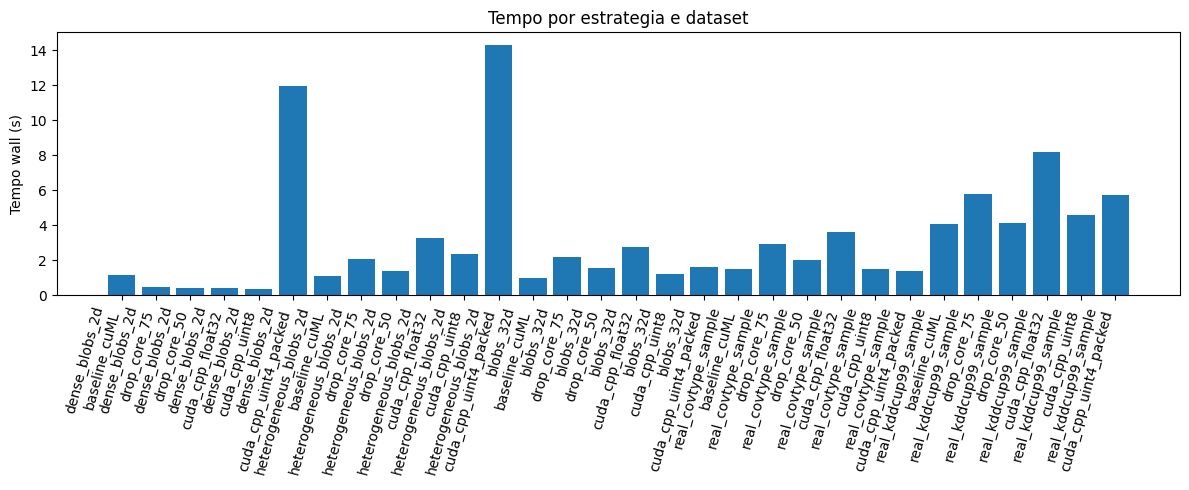

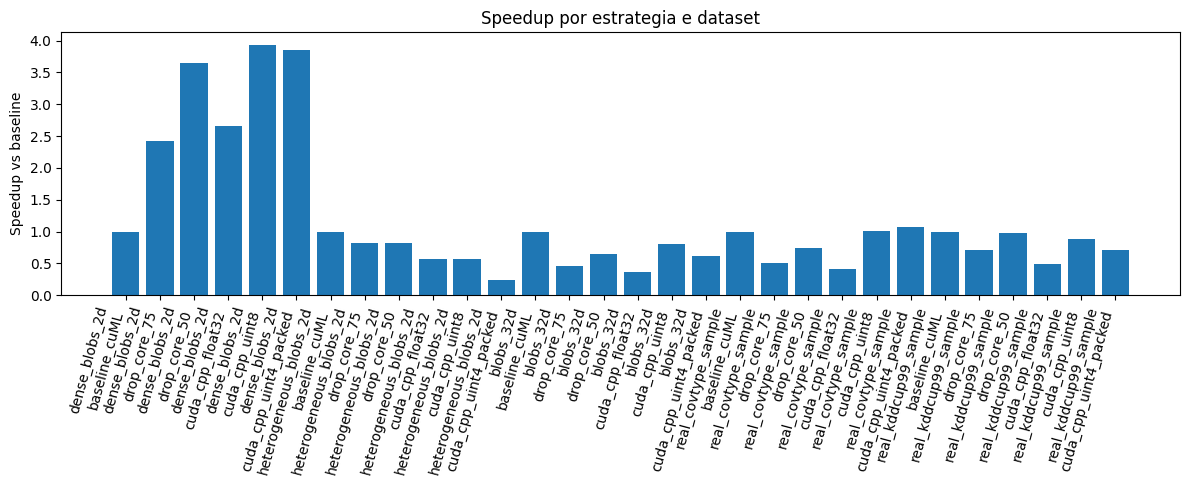

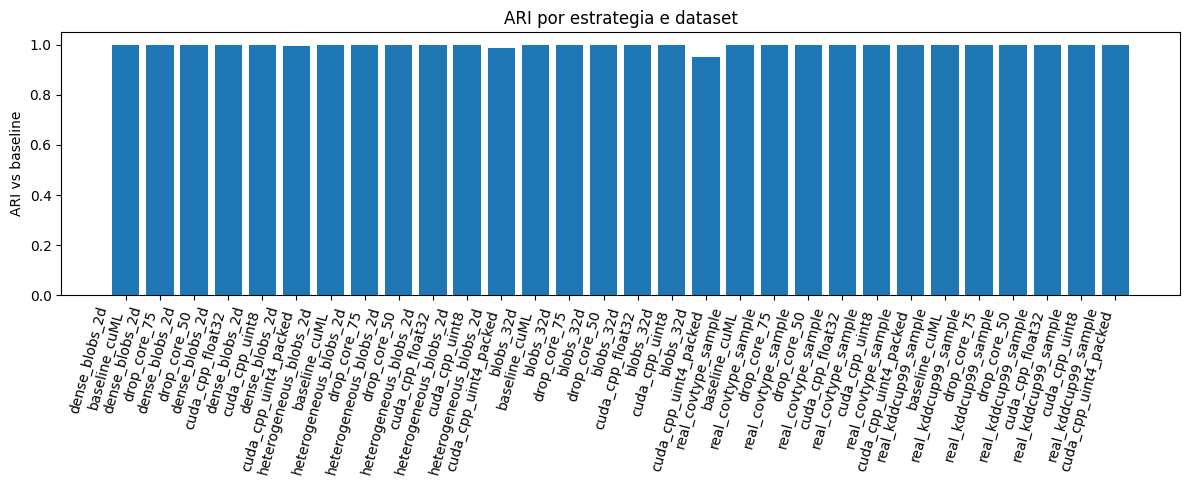

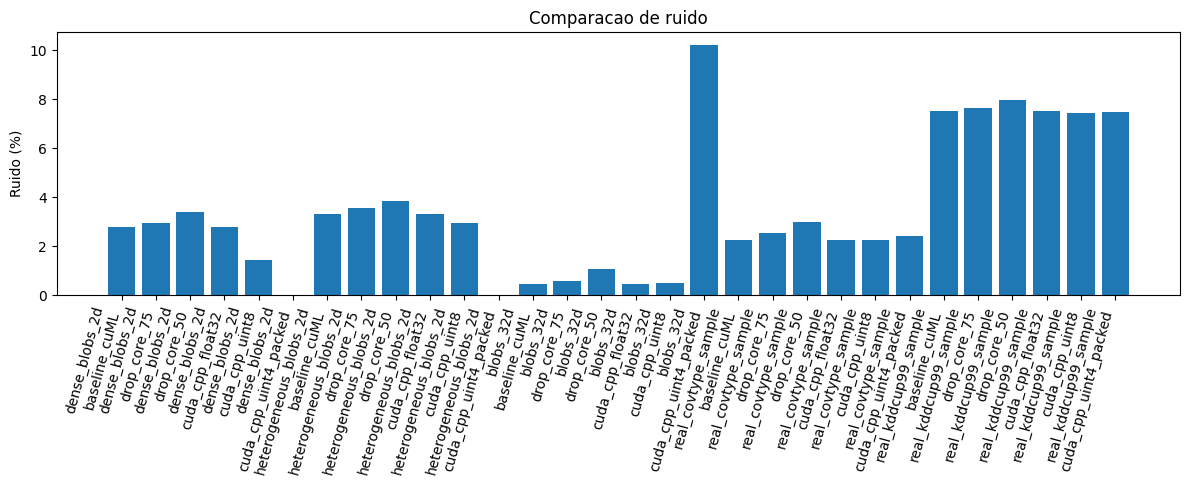

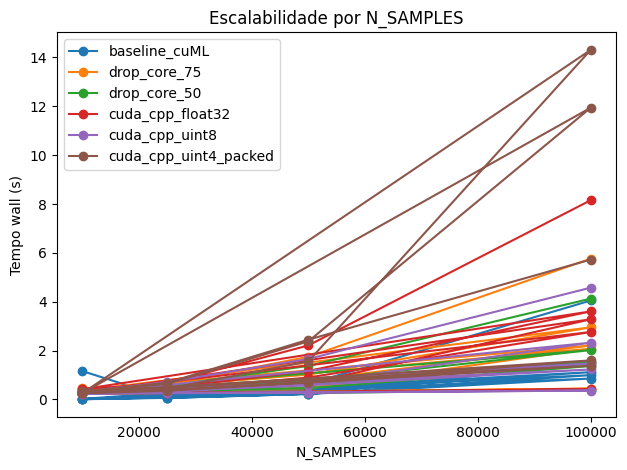

In [11]:
df_ok = df_benchmark[df_benchmark["status"] == "ok"].copy()
if len(df_ok):
    plt.figure(figsize=(12, 5))
    labels = df_ok["dataset_name"].astype(str) + "\n" + df_ok["estrategia"].astype(str)
    plt.bar(labels, df_ok["time_s_wall"])
    plt.xticks(rotation=75, ha="right")
    plt.ylabel("Tempo wall (s)")
    plt.title("Tempo por estrategia e dataset")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(12, 5))
    plt.bar(labels, df_ok["speedup_vs_baseline_wall"])
    plt.xticks(rotation=75, ha="right")
    plt.ylabel("Speedup vs baseline")
    plt.title("Speedup por estrategia e dataset")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(12, 5))
    plt.bar(labels, df_ok["ARI_vs_baseline"])
    plt.xticks(rotation=75, ha="right")
    plt.ylim(0, 1.05)
    plt.ylabel("ARI vs baseline")
    plt.title("ARI por estrategia e dataset")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(12, 5))
    plt.bar(labels, df_ok["noise_%"])
    plt.xticks(rotation=75, ha="right")
    plt.ylabel("Ruido (%)")
    plt.title("Comparacao de ruido")
    plt.tight_layout()
    plt.show()

    if df_ok["n_samples"].nunique() > 1:
        for strategy in df_ok["estrategia"].dropna().unique():
            subset = df_ok[df_ok["estrategia"] == strategy]
            plt.plot(subset["n_samples"], subset["time_s_wall"], marker="o", label=strategy)
        plt.xlabel("N_SAMPLES")
        plt.ylabel("Tempo wall (s)")
        plt.title("Escalabilidade por N_SAMPLES")
        plt.legend()
        plt.tight_layout()
        plt.show()